# t-SNE with DBSCAN Clustering and Evaluation

This notebook applies t-SNE dimensionality reduction followed by DBSCAN clustering to identify sepsis patient subpopulations.

The final hyperparameters were selected in the separate hyperparameter tuning notebook.

The workflow includes:

1. Load the prepared clustering dataset.
2. Create a two-dimensional t-SNE representation.
3. Apply DBSCAN using the selected parameters.
4. Evaluate the clustering quality.
5. Compare clinical outcomes across clusters.
6. Evaluate ICU survival across clusters.
7. Examine the clinical features that distinguish the clusters.
8. Save the essential results and plots.

## Setup and Data

### Import Required Libraries

In [1]:
from pathlib import Path

import numpy as np
import pandas as pd

# Visualization
import matplotlib.pyplot as plt
import seaborn as sns

# t-SNE dimensionality reduction
from sklearn.manifold import TSNE

# DBSCAN clustering
from sklearn.cluster import DBSCAN

# Internal clustering evaluation
from sklearn.metrics import (
    silhouette_score,
    davies_bouldin_score,
    calinski_harabasz_score
)

# Survival analysis
from lifelines import KaplanMeierFitter
from lifelines.statistics import multivariate_logrank_test

#### Observation :
- Imports libraries for data processing and visualization.
- Loads t-SNE for dimensionality reduction.
- Loads DBSCAN for patient clustering.
- Includes Silhouette, Davies-Bouldin, and Calinski-Harabasz scores for cluster evaluation.
- Includes Kaplan-Meier and log-rank tests for survival comparison across clusters.

### Set Plot Style

In [2]:
# Apply a clean visual style to all figures
sns.set_theme(style="whitegrid")

#### Observation :
- Sets a consistent Seaborn white-grid theme for all plots.
- Improves the readability and visual consistency of figures generated throughout the notebook.

### Set Project Folder Paths

In [3]:
# Move two levels upward to reach the project root
ROOT = Path.cwd().parents[1]

# Original eICU tables
DATA_DIR = ROOT / "data"

# Dataset created in the dataset creation notebook
DATASET_DIR = (
    ROOT
    / "results"
    / "module_2"
    / "dataset_creation"
)

# Results produced by this notebook
RESULTS_DIR = (
    ROOT
    / "results"
    / "module_2"
    / "tsne_dbscan"
)

# Plots produced by this notebook
PLOTS_DIR = (
    ROOT
    / "plots"
    / "module_2"
    / "tsne_dbscan"
)

# Create output folders if they do not already exist
RESULTS_DIR.mkdir(parents=True, exist_ok=True)
PLOTS_DIR.mkdir(parents=True, exist_ok=True)

print("Project root:", ROOT)
print("Dataset folder:", DATASET_DIR)
print("Results folder:", RESULTS_DIR)
print("Plots folder:", PLOTS_DIR)

Project root: C:\Users\samsa\Documents\ICU Clustering
Dataset folder: C:\Users\samsa\Documents\ICU Clustering\results\module_2\dataset_creation
Results folder: C:\Users\samsa\Documents\ICU Clustering\results\module_2\tsne_dbscan
Plots folder: C:\Users\samsa\Documents\ICU Clustering\plots\module_2\tsne_dbscan


#### Observation :
- Defines the main project, data, results, and plot directories using `Path`.
- Keeps input datasets and generated outputs in clearly separated folders.
- Creates the required results and plot directories automatically if they do not already exist.

### Load the Scaled Clustering Dataset

In [4]:
# Final min-max scaled dataset created in dataset_creation.ipynb
SCALED_DATA_PATH = (
    DATASET_DIR / "feature_data_scaled.csv"
)

# File containing the feature names used for clustering
FEATURE_NAMES_PATH = (
    DATASET_DIR / "clustering_feature_names.csv"
)

# Load the scaled patient dataset
scaled_df = pd.read_csv(SCALED_DATA_PATH)

# Load the list of clustering features
feature_names_df = pd.read_csv(FEATURE_NAMES_PATH)

print("Scaled dataset shape:", scaled_df.shape)

scaled_df.head()

Scaled dataset shape: (7648, 81)


,patientunitstayid,age,gender,admissionheight,admissionweight,min_BUN,min_Hgb,min_WBC x 1000,min_anion gap,min_bicarbonate,...,ethnicity_Hispanic,ethnicity_Native American,ethnicity_Other/Unknown,unittype_CCU-CTICU,unittype_CTICU,unittype_Cardiac ICU,unittype_MICU,unittype_Med-Surg ICU,unittype_Neuro ICU,unittype_SICU
0,151900,0.666667,1.0,0.271546,0.077035,0.055777,0.270588,0.028740,0.339286,0.512195,...,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0
1,210208,0.472222,0.0,0.267434,0.058982,0.039841,0.476471,0.016535,0.321429,0.512195,...,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0
2,179269,0.888889,1.0,0.254770,0.061000,0.183267,0.400000,0.023228,0.482143,0.439024,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0
3,172764,0.736111,1.0,0.275658,0.075577,0.039841,0.700000,0.073622,0.535714,0.317073,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0
4,166175,0.583333,0.0,0.304934,0.100695,0.023904,0.535294,0.043701,0.428571,0.414634,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0


#### Observation :
- Loads the scaled patient dataset and the saved list of clustering features.
- The dataset contains $7,648$ patients and $81$ columns.
- Displays the first few records to verify that the scaled data loaded correctly.

### Load the Clustering Feature Names

In [5]:
# The first column contains the saved clustering feature names
feature_cols = (
    feature_names_df.iloc[:, 0]
    .astype(str)
    .tolist()
)

print("Number of saved clustering features:", len(feature_cols))

feature_cols[:10]

Number of saved clustering features: 80


['age',
 'gender',
 'admissionheight',
 'admissionweight',
 'min_BUN',
 'min_Hgb',
 'min_WBC x 1000',
 'min_anion gap',
 'min_bicarbonate',
 'min_chloride']

#### Observation :
- Extracts the saved feature names used for clustering into a Python list.
- Confirms that $52$ features are included in the clustering analysis.
- Displays the first $10$ feature names to verify that the correct variables were loaded.

### Prepare the Clustering Matrix

In [6]:
# Unique eICU ICU-stay identifier
ID_COL = "patientunitstayid"

# Keep only feature names that actually exist in the scaled dataset
feature_cols = [
    feature
    for feature in feature_cols
    if feature in scaled_df.columns
]

# X contains only variables used for clustering
X = scaled_df[feature_cols].copy()

print("Patients:", len(X))
print("Clustering features:", X.shape[1])

Patients: 7648
Clustering features: 80


#### Observation :
- Defines `patientunitstayid` as the unique patient identifier.
- Keeps only clustering features that are present in the scaled dataset.
- Creates the clustering matrix `X` using only the selected clinical features.
- Confirms the final number of patients and features used for clustering.

### Verify the Clustering Matrix

In [9]:
# Confirm that the patient identifier is unique
print(
    "Duplicate patient IDs:",
    scaled_df[ID_COL].duplicated().sum()
)

# t-SNE requires complete numerical data
print(
    "Missing values:",
    X.isna().sum().sum()
)

print(
    "Infinite values:",
    np.isinf(X.to_numpy()).sum()
)

# Min-max scaling should produce values approximately between 0 and 1
print(
    "Minimum feature value:",
    X.min().min()
)

print(
    "Maximum feature value:",
    X.max().max()
)

Duplicate patient IDs: 0
Missing values: 0
Infinite values: 0
Minimum feature value: 0.0
Maximum feature value: 1.0000000000000002


#### Observation :
- Checks that patient IDs are unique.
- Confirms the clustering matrix contains no missing or infinite values.
- Verifies that the features remain within the expected $0–1$ range after min-max scaling.
- Confirms the dataset is valid and ready for t-SNE and DBSCAN analysis.

## t-SNE Representation

### Set the Final t-SNE Parameters

In [10]:
# Final parameters selected during hyperparameter tuning
TSNE_COMPONENTS = 2
TSNE_PERPLEXITY = 80

# Fixed seed makes the t-SNE representation reproducible
RANDOM_STATE = 42

print("t-SNE dimensions:", TSNE_COMPONENTS)
print("t-SNE perplexity:", TSNE_PERPLEXITY)
print("Random state:", RANDOM_STATE)

t-SNE dimensions: 2
t-SNE perplexity: 80
Random state: 42


#### Observation :
- Sets the final t-SNE configuration to create a $2$-dimensional representation of the patient data.
- Uses a perplexity of $80$, selected from the earlier hyperparameter tuning.
- Sets `random_state = 42` to make the t-SNE results reproducible.

### Create the Two-Dimensional t-SNE Representation

In [11]:
# Create the t-SNE model
tsne = TSNE(
    n_components=TSNE_COMPONENTS,
    perplexity=TSNE_PERPLEXITY,
    metric="euclidean",
    init="pca",
    learning_rate="auto",
    max_iter=1000,
    random_state=RANDOM_STATE
)

# Reduce the clustering matrix to two dimensions
tsne_embedding = tsne.fit_transform(X)

print("Original feature matrix:", X.shape)
print("t-SNE representation:", tsne_embedding.shape)

Original feature matrix: (7648, 80)
t-SNE representation: (7648, 2)


#### Observation :
- Applies t-SNE to reduce the $80$-dimensional patient data to $2$ dimensions.
- Uses Euclidean distance, PCA initialization, and $1,000$ iterations for the transformation.
- Converts the original $7,648 \times 80$ feature matrix into a $7,648 \times 2$ t-SNE representation for clustering and visualization.

### Create the t-SNE Results Table

In [12]:
# Store patient ID and the two t-SNE coordinates
tsne_results = pd.DataFrame({
    ID_COL: scaled_df[ID_COL].values,
    "tsne_1": tsne_embedding[:, 0],
    "tsne_2": tsne_embedding[:, 1]
})

tsne_results.head()

,patientunitstayid,tsne_1,tsne_2
0,151900,-56.713261,13.869975
1,210208,-47.642979,-9.039283
2,179269,19.944166,24.854603
3,172764,25.943287,27.785046
4,166175,17.742785,-20.130337


#### Observation :
- Creates a dataframe containing each patient’s ID and two t-SNE coordinates.
- Preserves the link between the reduced t-SNE representation and the original patient records.
- Prepares the t-SNE output for visualization and DBSCAN clustering.

### Plot the t-SNE Representation

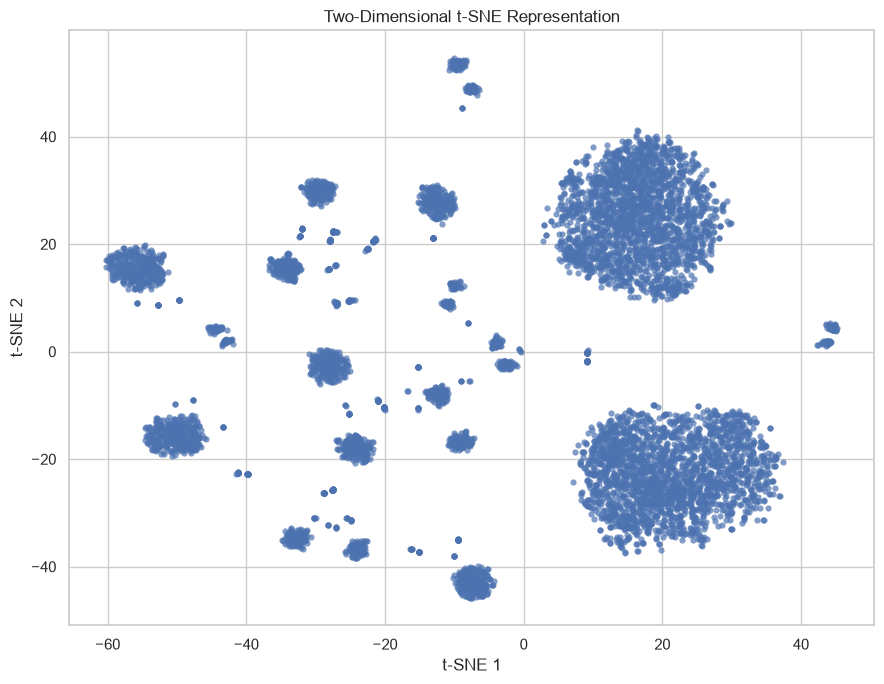

In [13]:
plt.figure(figsize=(9, 7))

# Plot all patients before applying DBSCAN
sns.scatterplot(
    data=tsne_results,
    x="tsne_1",
    y="tsne_2",
    s=20,
    alpha=0.7,
    linewidth=0
)

plt.title("Two-Dimensional t-SNE Representation")
plt.xlabel("t-SNE 1")
plt.ylabel("t-SNE 2")

plt.tight_layout()

# Save the figure
plt.savefig(
    PLOTS_DIR / "tsne_representation.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

#### Observation :
- Visualizes the 2D t-SNE representation of all patients before DBSCAN clustering.
- Shows how patients are distributed in the reduced feature space and whether any natural grouping patterns are visible.
- Saves the t-SNE plot for further interpretation and reporting.

## DBSCAN Clustering

### Set the Final DBSCAN Parameters

In [14]:
# Final parameters selected during hyperparameter tuning
DBSCAN_EPS = 3.0
DBSCAN_MIN_SAMPLES = 40

print("DBSCAN epsilon:", DBSCAN_EPS)
print("DBSCAN min_samples:", DBSCAN_MIN_SAMPLES)

DBSCAN epsilon: 3.0
DBSCAN min_samples: 40


#### Observation :
- Sets the final DBSCAN parameters selected during hyperparameter tuning.
- Uses epsilon (`eps`) = $3.0$ to define the neighborhood distance.
- Uses `min_samples` = $40$ to determine the minimum number of nearby patients required to form a dense region.

### Apply DBSCAN to the t-SNE Representation

In [15]:
# Create the DBSCAN model
dbscan = DBSCAN(
    eps=DBSCAN_EPS,
    min_samples=DBSCAN_MIN_SAMPLES,
    metric="euclidean"
)

# Assign each patient to a cluster
cluster_labels = dbscan.fit_predict(
    tsne_embedding
)

# Add cluster labels to the results table
tsne_results["cluster"] = cluster_labels

tsne_results.head()

,patientunitstayid,tsne_1,tsne_2,cluster
0,151900,-56.713261,13.869975,0
1,210208,-47.642979,-9.039283,3
2,179269,19.944166,24.854603,1
3,172764,25.943287,27.785046,1
4,166175,17.742785,-20.130337,2


#### Observation :
- Applies DBSCAN clustering to the 2D t-SNE representation using the selected parameters.
- Assigns each patient a cluster label, with $-1$ representing patients identified as outliers.
- Adds the cluster labels to the t-SNE results table for further cluster analysis.

### Summarize the Clustering Result

In [16]:
# Number of actual clusters
# DBSCAN uses -1 for outliers, so -1 is not counted
n_clusters = len(set(cluster_labels)) - (
    1 if -1 in cluster_labels else 0
)

# Count DBSCAN outliers
n_outliers = np.sum(
    cluster_labels == -1
)

# Percentage of patients identified as outliers
outlier_percentage = (
    n_outliers / len(cluster_labels)
) * 100

print("Patients:", len(tsne_results))
print("Number of clusters:", n_clusters)
print("Number of outliers:", n_outliers)
print(
    "Outlier percentage:",
    round(outlier_percentage, 2),
    "%"
)

Patients: 7648
Number of clusters: 22
Number of outliers: 310
Outlier percentage: 4.05 %


#### Observation :
- DBSCAN identifies $22$ patient clusters from $7,648$ patients.
- $310$ patients are classified as outliers.
- The outlier rate is $4.05\%$, meaning most patients are assigned to a defined cluster.

### Check Cluster Sizes

In [17]:
# Count the number of patients in every cluster
cluster_distribution = (
    tsne_results["cluster"]
    .value_counts()
    .sort_index()
    .rename("patients")
    .to_frame()
)

cluster_distribution

,patients
cluster,
-1,310
0,363
1,2060
2,2128
3,350
4,87
5,173
6,232
7,98


`Cluster -1` represents DBSCAN outliers

#### Observation :
- Calculates the number of patients in each DBSCAN cluster.
- Cluster sizes vary substantially, with Cluster $2$ ($2,128$ patients) and Cluster $1$ ($2,060$ patients) being the largest.
- Several clusters are much smaller, indicating uneven patient subgroup sizes.
- $310$ patients remain in the outlier group (Cluster $-1$).

### Plot the t-SNE DBSCAN Clusters

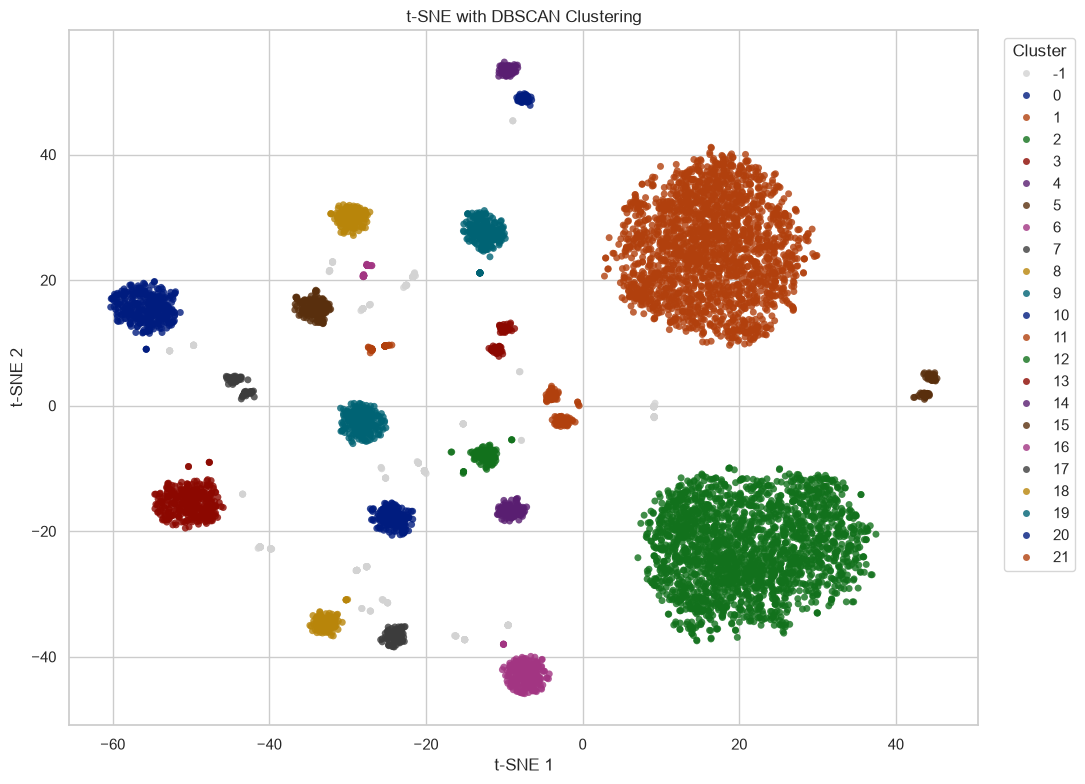

In [19]:
# Get the actual cluster numbers
normal_clusters = sorted(
    [
        cluster
        for cluster in tsne_results["cluster"].unique()
        if cluster != -1
    ]
)

# Create one color for each cluster
colors = sns.color_palette(
    "dark",
    len(normal_clusters)
)

cluster_palette = dict(
    zip(normal_clusters, colors)
)

# Display outliers in gray
cluster_palette[-1] = "lightgray"


plt.figure(figsize=(11, 8))

# Plot patients using their DBSCAN cluster as color
sns.scatterplot(
    data=tsne_results,
    x="tsne_1",
    y="tsne_2",
    hue="cluster",
    palette=cluster_palette,
    s=25,
    alpha=0.8,
    linewidth=0
)

plt.title("t-SNE with DBSCAN Clustering")
plt.xlabel("t-SNE 1")
plt.ylabel("t-SNE 2")

# Place the cluster legend outside the main plot
plt.legend(
    title="Cluster",
    bbox_to_anchor=(1.02, 1),
    loc="upper left"
)

plt.tight_layout()

plt.savefig(
    PLOTS_DIR / "tsne_dbscan_clusters.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

#### Observation :
- Visualizes the $22$ DBSCAN clusters in the 2D t-SNE space.
- Assigns a different color to each cluster and shows outliers in gray.
- Makes the separation and spatial distribution of patient subgroups easier to interpret.
- Saves the final clustered t-SNE visualization for reporting.

## Internal Cluster Evaluation

### Remove DBSCAN Outliers for Evaluation

In [20]:
# Outliers are not treated as a normal cluster
evaluation_mask = (
    tsne_results["cluster"] != -1
)

# Use the t-SNE coordinates for internal cluster evaluation
X_evaluation = tsne_results.loc[
    evaluation_mask,
    ["tsne_1", "tsne_2"]
]

# Corresponding DBSCAN cluster labels
labels_evaluation = tsne_results.loc[
    evaluation_mask,
    "cluster"
]

print(
    "Patients used for evaluation:",
    len(X_evaluation)
)

print(
    "Clusters evaluated:",
    labels_evaluation.nunique()
)

Patients used for evaluation: 7338
Clusters evaluated: 22


#### Observation :
- Removes the $310$ DBSCAN outliers before internal cluster evaluation.
- Uses the 2D t-SNE coordinates and corresponding DBSCAN cluster labels for evaluation.
- Evaluates $7,338$ patients across $22$ clusters.

### Calculate Internal Evaluation Metrics

In [21]:
# Higher Silhouette Score is better
silhouette = silhouette_score(
    X_evaluation,
    labels_evaluation
)

# Lower Davies-Bouldin Index is better
dbi = davies_bouldin_score(
    X_evaluation,
    labels_evaluation
)

# Higher Calinski-Harabasz Index is better
chi = calinski_harabasz_score(
    X_evaluation,
    labels_evaluation
)

print(
    "Silhouette Score:",
    round(silhouette, 4)
)

print(
    "Davies-Bouldin Index:",
    round(dbi, 4)
)

print(
    "Calinski-Harabasz Index:",
    round(chi, 2)
)

Silhouette Score: 0.6621
Davies-Bouldin Index: 0.2744
Calinski-Harabasz Index: 8528.12


#### Observation :
- Calculates three internal clustering evaluation metrics for the $22$ DBSCAN clusters.
- The Silhouette Score is $0.6621$, indicating good separation between clusters.
- The Davies-Bouldin Index is $0.2744$, indicating low overlap between clusters.
- The Calinski-Harabasz Index is $8528.12$, showing strong separation and compactness of the identified patient groups.

### Compare with Ju and Dubin

In [22]:
evaluation_summary = pd.DataFrame({

    "metric": [
        "Number of clusters",
        "Silhouette Score",
        "Davies-Bouldin Index",
        "Calinski-Harabasz Index"
    ],

    "our_replication": [
        n_clusters,
        silhouette,
        dbi,
        chi
    ],

    "ju_dubin_paper": [
        22,
        0.67,
        0.25,
        8576.69
    ]
})

evaluation_summary.round(4)

,metric,our_replication,ju_dubin_paper
0,Number of clusters,22.0000,22.00
1,Silhouette Score,0.6621,0.67
2,Davies-Bouldin Index,0.2744,0.25
3,Calinski-Harabasz Index,8528.1201,8576.69


#### Observation :
- Compares the obtained clustering results with the Ju and Dubin study.
- Both approaches identify $22$ clusters.
- The obtained Silhouette Score ($0.6621$) is very close to the reported $0.67$.
- The Davies-Bouldin Index ($0.2744$) and Calinski-Harabasz Index ($8528.12$) are also close to the study values, indicating a strong replication of the original clustering performance.

## Clinical Outcome Evaluation

### Load the Required Clinical Data

In [23]:
# Load only the patient variables required for outcome evaluation
patient = pd.read_csv(
    DATA_DIR / "patient.csv",
    usecols=[
        "patientunitstayid",
        "age",
        "unitdischargeoffset",
        "hospitaldischargeoffset",
        "unitdischargestatus",
        "hospitaldischargestatus"
    ]
)

# Load APACHE illness-severity information
apache = pd.read_csv(
    DATA_DIR / "apachePatientResult.csv",
    usecols=[
        "patientunitstayid",
        "apacheversion",
        "apachescore"
    ]
)

print("Patient table:", patient.shape)
print("APACHE table:", apache.shape)

Patient table: (200859, 6)
APACHE table: (297064, 3)


#### Observation :
- Loads the required patient demographic and clinical outcome variables from the patient table.
- Loads APACHE severity scores for assessing illness severity.
- The patient table contains $200,859$ records, while the APACHE table contains $297,064$ records.
- These variables are prepared for evaluating the clinical differences between the identified patient clusters.

### Prepare Age and Length of Stay (LOS)

In [24]:
# Create a copy before modifying the patient table
outcomes = patient.copy()

# eICU represents ages above 89 as "> 89"
# Convert this category into a numeric value
outcomes["age"] = outcomes["age"].replace(
    "> 89",
    "90"
)

outcomes["age"] = pd.to_numeric(
    outcomes["age"],
    errors="coerce"
)

# Convert discharge offsets from minutes into days
outcomes["icu_los_days"] = (
    outcomes["unitdischargeoffset"] / 1440
)

outcomes["hospital_los_days"] = (
    outcomes["hospitaldischargeoffset"] / 1440
)

#### Observation :
- Creates a separate outcomes dataset from the patient table for clinical evaluation.
- Converts the eICU age category $\gt 89$ to $90$ so age can be analyzed numerically.
- Converts age and discharge offset variables to numeric format.
- Prepares the patient-level clinical variables for mortality, length-of-stay, and cluster outcome analysis.

### Prepare Mortality Variables

In [25]:
# ICU mortality:
# Alive = 0
# Expired = 1
outcomes["icu_mortality"] = (
    outcomes["unitdischargestatus"]
    .map({
        "Alive": 0,
        "Expired": 1
    })
)

# Hospital mortality
outcomes["hospital_mortality"] = (
    outcomes["hospitaldischargestatus"]
    .map({
        "Alive": 0,
        "Expired": 1
    })
)

print("ICU mortality:")
print(
    outcomes["icu_mortality"]
    .value_counts(dropna=False)
)

print()

print("Hospital mortality:")
print(
    outcomes["hospital_mortality"]
    .value_counts(dropna=False)
)

ICU mortality:
icu_mortality
0.0    189918
1.0     10907
NaN        34
Name: count, dtype: int64

Hospital mortality:
hospital_mortality
0.0    181104
1.0     18004
NaN      1751
Name: count, dtype: int64


#### Observation :
- Converts ICU and hospital discharge status into binary mortality variables.
- Assigns `0` to survivors and `1` to patients who died.
- ICU mortality includes $10,907$ deaths, while hospital mortality includes $18,004$ deaths.
- Missing mortality values are retained as `NaN` for appropriate handling in later analysis.

### Prepare APACHE IVa Scores

In [26]:
# Keep APACHE IVa records
apache_iva = apache[
    apache["apacheversion"] == "IVa"
][
    [
        "patientunitstayid",
        "apachescore"
    ]
].copy()

# Keep one APACHE score per ICU stay
apache_iva = apache_iva.drop_duplicates(
    subset="patientunitstayid"
)

# Rename the column for clarity
apache_iva = apache_iva.rename(
    columns={
        "apachescore": "apache_iva"
    }
)

print(
    "Patients with APACHE IVa:",
    len(apache_iva)
)

Patients with APACHE IVa: 148532


#### Observation :
- Filters the APACHE data to retain only APACHE IVa scores.
- Keeps one APACHE IVa score per ICU stay to avoid duplicate patient records.
- Renames the score column to `apache_iva` for clarity.
- APACHE IVa scores are available for $148,532$ ICU stays.

### Merge Clinical Outcomes with Cluster Assignments

In [27]:
# Combine cluster assignments with patient outcomes
clinical_results = (
    tsne_results
    .merge(
        outcomes,
        on=ID_COL,
        how="left"
    )
    .merge(
        apache_iva,
        on=ID_COL,
        how="left"
    )
)

print(
    "Patients after clinical merge:",
    len(clinical_results)
)

clinical_results.head()

Patients after clinical merge: 7648


,patientunitstayid,tsne_1,tsne_2,cluster,age,hospitaldischargeoffset,hospitaldischargestatus,unitdischargeoffset,unitdischargestatus,icu_los_days,hospital_los_days,icu_mortality,hospital_mortality,apache_iva
0,151900,-56.713261,13.869975,0,66.0,6355,Alive,3460,Alive,2.402778,4.413194,0.0,0.0,68.0
1,210208,-47.642979,-9.039283,3,52.0,8352,Alive,5478,Alive,3.804167,5.800000,0.0,0.0,49.0
2,179269,19.944166,24.854603,1,82.0,24087,Alive,3655,Alive,2.538194,16.727083,0.0,0.0,117.0
3,172764,25.943287,27.785046,1,71.0,10974,Alive,2077,Alive,1.442361,7.620833,0.0,0.0,NaN
4,166175,17.742785,-20.130337,2,60.0,10037,Alive,1175,Alive,0.815972,6.970139,0.0,0.0,47.0


#### Observation :
- Merges the t-SNE cluster assignments with patient demographics, mortality, length-of-stay, and APACHE IVa severity scores.
- Creates one combined clinical dataset for comparing outcomes across the identified clusters.
- Preserves all clustered patients using a left join, even when some clinical variables are missing.

### Create the Cluster Outcome Summary

In [28]:
# Remove DBSCAN outliers from clinical cluster interpretation
cluster_clinical = clinical_results[
    clinical_results["cluster"] != -1
].copy()

# Create one summary row for each cluster
clinical_summary = (
    cluster_clinical
    .groupby("cluster")
    .agg(
        patients=(ID_COL, "size"),
        mean_age=("age", "mean"),
        mean_apache_iva=("apache_iva", "mean"),
        mean_icu_los=("icu_los_days", "mean"),
        mean_hospital_los=("hospital_los_days", "mean"),
        icu_mortality=("icu_mortality", "mean"),
        hospital_mortality=("hospital_mortality", "mean")
    )
    .reset_index()
)

# Calculate the percentage of clustered patients in each cluster
clinical_summary["patient_percentage"] = (
    clinical_summary["patients"]
    / clinical_summary["patients"].sum()
    * 100
)

# Convert mortality proportions into percentages
clinical_summary["icu_mortality"] *= 100
clinical_summary["hospital_mortality"] *= 100

# Arrange the columns
clinical_summary = clinical_summary[
    [
        "cluster",
        "patients",
        "patient_percentage",
        "mean_age",
        "mean_apache_iva",
        "mean_icu_los",
        "mean_hospital_los",
        "icu_mortality",
        "hospital_mortality"
    ]
]

clinical_summary.round(2)

,cluster,patients,patient_percentage,mean_age,mean_apache_iva,mean_icu_los,mean_hospital_los,icu_mortality,hospital_mortality
0,0,363,4.95,67.09,75.55,3.94,9.17,14.33,19.67
1,1,2060,28.07,66.49,73.14,3.68,8.34,13.01,19.26
2,2,2128,29.00,66.33,73.57,3.99,8.71,12.55,18.90
3,3,350,4.77,67.23,75.79,4.19,10.53,15.14,19.83
4,4,87,1.19,64.51,73.37,4.65,10.92,14.94,19.54
5,5,173,2.36,61.27,79.81,3.95,9.83,12.14,21.43
6,6,232,3.16,66.68,73.14,4.24,8.76,10.34,20.69
7,7,98,1.34,59.97,73.90,4.53,12.26,23.47,27.55
8,8,170,2.32,59.53,70.68,4.29,10.47,10.00,19.41
9,9,237,3.23,65.58,72.23,4.00,8.59,10.97,17.30


#### Observation :
- Removes DBSCAN outliers from the clinical comparison.
- Summarizes each cluster by patient count, age, APACHE IVa severity, ICU stay, hospital stay, and mortality.
- Converts ICU and hospital mortality rates into percentages for easier clinical interpretation.
- Calculates the proportion of patients in each cluster to show the relative size of each patient subgroup.

### Plot Hospital Mortality Across Clusters

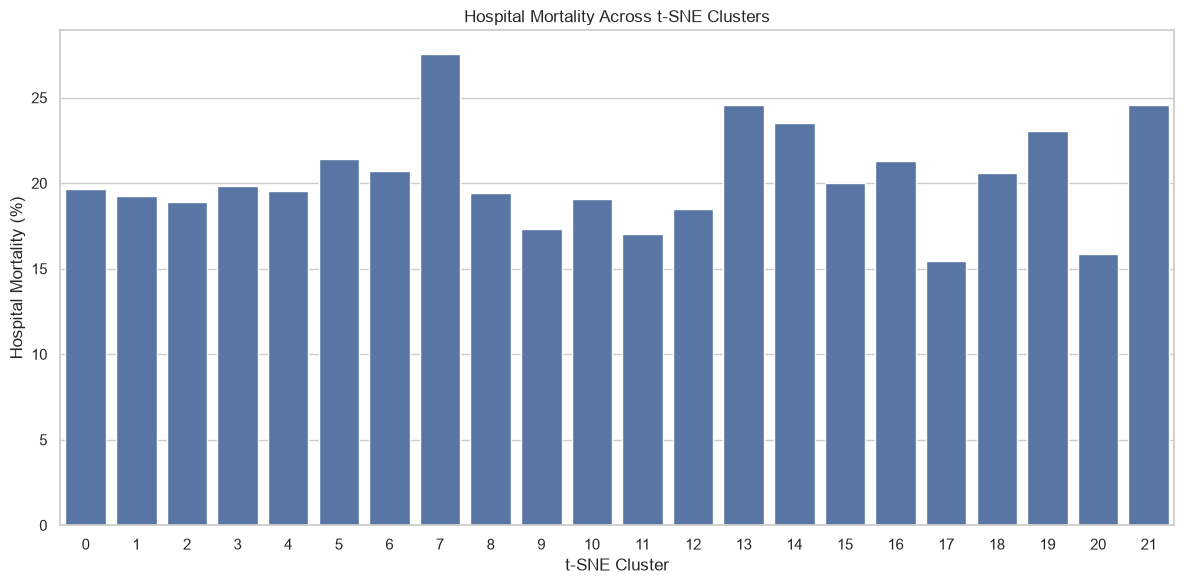

In [29]:
plt.figure(figsize=(12, 6))

# Compare hospital mortality across patient clusters
sns.barplot(
    data=clinical_summary,
    x="cluster",
    y="hospital_mortality",
    errorbar=None
)

plt.title(
    "Hospital Mortality Across t-SNE Clusters"
)

plt.xlabel("t-SNE Cluster")
plt.ylabel("Hospital Mortality (%)")

plt.tight_layout()

plt.savefig(
    PLOTS_DIR / "tsne_hospital_mortality.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

#### Observation :
- Compares hospital mortality rates across the $22$ patient clusters.
- Shows clear variation in mortality between clusters, indicating that the identified subgroups have different clinical risk profiles.
- Highlights clusters with relatively higher and lower hospital mortality, supporting the clinical relevance of the DBSCAN clustering.

## ICU Survival Evaluation

### Prepare ICU Survival Data

In [30]:
# Keep patients with valid survival information
# and exclude DBSCAN outliers
survival_data = clinical_results[
    (clinical_results["cluster"] != -1)
    & clinical_results["icu_los_days"].notna()
    & clinical_results["icu_mortality"].notna()
    & (clinical_results["icu_los_days"] >= 0)
].copy()

print(
    "Patients:",
    len(survival_data)
)

print(
    "Number of clusters:",
    survival_data["cluster"].nunique()
)

print(
    "ICU deaths:",
    int(
        survival_data["icu_mortality"].sum()
    )
)

print(
    "Minimum ICU LOS:",
    survival_data["icu_los_days"].min()
)

print(
    "Maximum ICU LOS:",
    survival_data["icu_los_days"].max()
)

Patients: 7338
Number of clusters: 22
ICU deaths: 949
Minimum ICU LOS: 0.0
Maximum ICU LOS: 246.90416666666667


#### Observation :
- Prepares the dataset for ICU survival analysis by excluding DBSCAN outliers and records with invalid survival information.
- Includes $7,338$ patients across $22$ clusters.
- Records $949$ ICU deaths for the survival analysis.
- ICU length of stay ranges from $0$ to $246.9$ days.

### Plot Kaplan-Meier Survival Curves

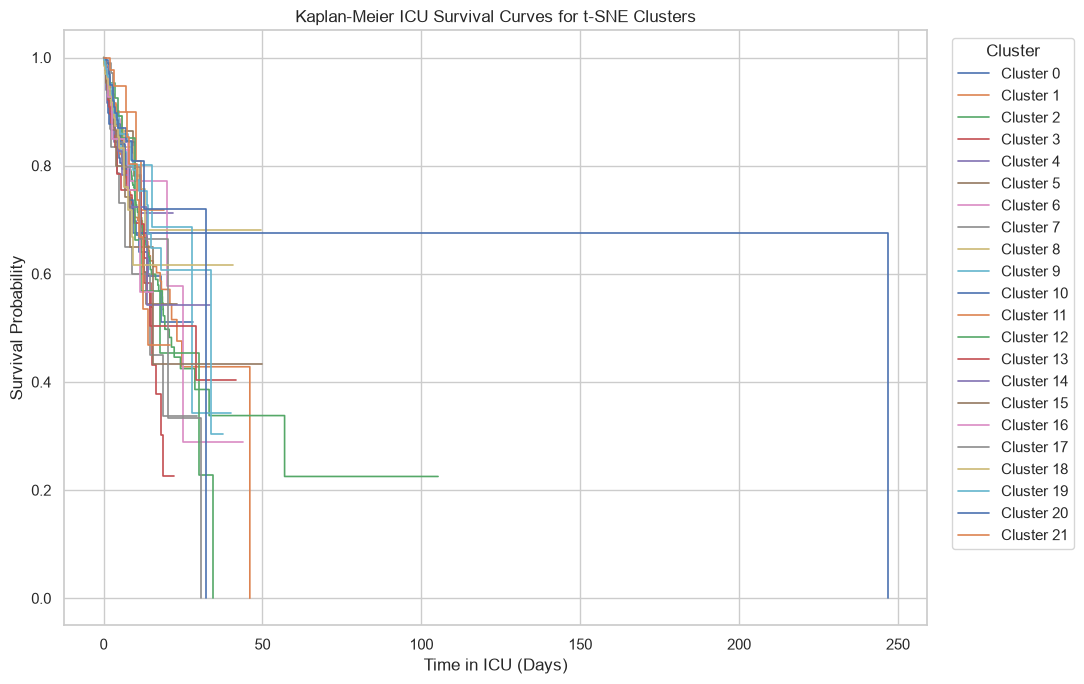

In [31]:
# Create the Kaplan-Meier estimator
kmf = KaplanMeierFitter()

fig, ax = plt.subplots(
    figsize=(11, 7)
)

# Create one survival curve for each cluster
for cluster in sorted(
    survival_data["cluster"].unique()
):

    cluster_data = survival_data[
        survival_data["cluster"] == cluster
    ]

    kmf.fit(
        durations=cluster_data["icu_los_days"],
        event_observed=cluster_data["icu_mortality"],
        label=f"Cluster {cluster}"
    )

    # Confidence intervals are hidden because
    # many clusters are displayed together
    kmf.plot_survival_function(
        ax=ax,
        ci_show=False,
        linewidth=1.2
    )

ax.set_title(
    "Kaplan-Meier ICU Survival Curves for t-SNE Clusters"
)

ax.set_xlabel("Time in ICU (Days)")
ax.set_ylabel("Survival Probability")

ax.legend(
    title="Cluster",
    bbox_to_anchor=(1.02, 1),
    loc="upper left"
)

plt.tight_layout()

plt.savefig(
    PLOTS_DIR / "tsne_kaplan_meier.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

#### Observation :
- Generates Kaplan-Meier survival curves for all $22$ t-SNE–DBSCAN patient clusters.
- Compares ICU survival probability over time between the identified patient subgroups.
- Confidence intervals are omitted to keep the multi-cluster visualization readable.
- The curves provide a visual assessment of whether clusters show different ICU survival patterns.

### Perform the Global Log-Rank Test

In [32]:
# Test whether ICU survival differs across the clusters
logrank_result = multivariate_logrank_test(
    survival_data["icu_los_days"],
    survival_data["cluster"],
    survival_data["icu_mortality"]
)

print(
    "Patients:",
    len(survival_data)
)

print(
    "Clusters:",
    survival_data["cluster"].nunique()
)

print(
    "ICU deaths:",
    int(
        survival_data["icu_mortality"].sum()
    )
)

print(
    "Log-rank statistic:",
    round(
        logrank_result.test_statistic,
        4
    )
)

print(
    "Log-rank p-value:",
    logrank_result.p_value
)

Patients: 7338
Clusters: 22
ICU deaths: 949
Log-rank statistic: 21.9247
Log-rank p-value: 0.4038589768514318


#### Observation :
- Performs a global log-rank test to compare ICU survival across the 22 patient clusters.
- The test produces a p-value of $0.4039$.
- Since the p-value is greater than $0.05$, there is no statistically significant difference in ICU survival across the clusters.

## Clinical Interpretation

### Add Cluster Labels to the Clustering Features

In [33]:
# Copy the original scaled clustering features
cluster_features = scaled_df[
    [ID_COL] + feature_cols
].copy()

# Add the t-SNE DBSCAN cluster labels
cluster_features["cluster"] = (
    tsne_results["cluster"].values
)

# Remove DBSCAN outliers
cluster_features = cluster_features[
    cluster_features["cluster"] != -1
].copy()

print(
    "Patients used for clinical interpretation:",
    len(cluster_features)
)

print(
    "Clusters:",
    cluster_features["cluster"].nunique()
)

Patients used for clinical interpretation: 7338
Clusters: 22


#### Observation :
- Combines the original scaled clinical features with the DBSCAN cluster labels.
- Keeps patient IDs so each cluster assignment remains linked to the correct patient.
- Removes DBSCAN outliers before interpreting the clinical characteristics of the clusters.

### Standard Features for Interpretation

THe clustering data are already min-max scaled. This second standardization is only used to make cluster profiles easier to compare.

In [34]:
# Overall mean of each clustering feature
feature_mean = X.mean()

# Overall standard deviation of each feature
feature_std = X.std().replace(
    0,
    np.nan
)

# Standardized interpretation matrix
# 0 = cohort average
# positive = above cohort average
# negative = below cohort average
X_standardized = (
    X - feature_mean
) / feature_std

# Add the cluster labels
X_standardized["cluster"] = (
    tsne_results["cluster"].values
)

# Remove outliers
X_standardized = X_standardized[
    X_standardized["cluster"] != -1
]

X_standardized.head()

,age,gender,admissionheight,admissionweight,min_BUN,min_Hgb,min_WBC x 1000,min_anion gap,min_bicarbonate,min_chloride,...,ethnicity_Native American,ethnicity_Other/Unknown,unittype_CCU-CTICU,unittype_CTICU,unittype_Cardiac ICU,unittype_MICU,unittype_Med-Surg ICU,unittype_Neuro ICU,unittype_SICU,cluster
0,0.043316,1.014687,-0.232191,0.123306,-0.744668,-1.132370,-0.684715,-0.140295,0.387933,-0.312693,...,-0.118544,-0.218323,-0.279163,-0.090398,-0.279978,2.798282,-1.466164,-0.155241,-0.168428,0
1,-0.826669,-0.985397,-0.411240,-0.409269,-0.914413,0.510064,-0.966577,-0.353228,0.387933,-1.011505,...,-0.118544,-0.218323,-0.279163,-0.090398,-0.279978,2.798282,-1.466164,-0.155241,-0.168428,3
2,1.037584,1.014687,-0.962713,-0.349726,0.613290,-0.099983,-0.812008,1.563175,-0.154015,0.805407,...,-0.118544,-0.218323,-0.279163,-0.090398,-0.279978,-0.357315,0.681963,-0.155241,-0.168428,1
3,0.354024,1.014687,-0.053141,0.080303,-0.914413,2.293277,0.351810,2.201976,-1.057262,-0.452455,...,-0.118544,-0.218323,-0.279163,-0.090398,-0.279978,-0.357315,0.681963,-0.155241,-0.168428,1
4,-0.329535,-0.985397,1.221691,0.821277,-1.084158,0.979330,-0.339207,0.924374,-0.334664,-1.291030,...,-0.118544,-0.218323,-0.279163,-0.090398,-0.279978,-0.357315,0.681963,-0.155241,-0.168428,2


#### Observation :
- Standardizes the clustering features relative to the overall patient cohort.
- A standardized value of $0$ represents the cohort average, while positive or negative values indicate above- or below-average feature levels.
- This transformation makes the clinical characteristics of different clusters easier to compare and interpret.

### Calculate Mean Cluster Feature Profiles

In [35]:
# Calculate the average standardized value of every feature within each cluster
cluster_profiles = (
    X_standardized
    .groupby("cluster")
    .mean()
)

print(
    "Cluster profile shape:",
    cluster_profiles.shape
)

cluster_profiles.head()

Cluster profile shape: (22, 80)


,age,gender,admissionheight,admissionweight,min_BUN,min_Hgb,min_WBC x 1000,min_anion gap,min_bicarbonate,min_chloride,...,ethnicity_Hispanic,ethnicity_Native American,ethnicity_Other/Unknown,unittype_CCU-CTICU,unittype_CTICU,unittype_Cardiac ICU,unittype_MICU,unittype_Med-Surg ICU,unittype_Neuro ICU,unittype_SICU
cluster,,,,,,,,,,,,,,,,,,,,,
0,0.111107,1.014687,-0.474712,-0.101286,-0.019278,-0.153373,0.089723,-0.054065,-0.172329,0.072713,...,-0.211667,-0.047858,-0.218323,-0.279163,-0.090398,-0.279978,2.798282,-1.466164,-0.155241,-0.168428
1,0.073934,1.014687,-0.508409,-0.193337,-0.106803,-0.094744,0.023678,0.054240,-0.020036,-0.009015,...,-0.211667,-0.118544,-0.218323,-0.279163,-0.090398,-0.279978,-0.357315,0.681963,-0.155241,-0.168428
2,0.063932,-0.985397,0.555472,0.224321,0.074749,0.183363,-0.008044,-0.045455,0.098232,-0.102721,...,-0.211667,-0.118544,-0.218323,-0.279163,-0.090398,-0.279978,-0.357315,0.681963,-0.155241,-0.168428
3,0.119839,-0.985397,0.546779,0.299390,0.157647,0.145108,0.042814,-0.164021,-0.017754,-0.063916,...,-0.211667,-0.069670,-0.218323,-0.279163,-0.090398,-0.279978,2.798282,-1.466164,-0.155241,-0.168428
4,-0.049540,-0.985397,0.668325,0.379765,0.045035,-0.028245,-0.068548,-0.179455,0.073769,-0.034774,...,-0.211667,-0.118544,-0.218323,-0.279163,-0.090398,-0.279978,-0.357315,-1.466164,-0.155241,5.936484


#### Observation :
- Calculates the average standardized value of all $80$ clinical features within each cluster.
- Produces a $22 \times 80$ cluster profile matrix, representing $22$ patient clusters across $80$ features.
- These mean profiles are used to identify the clinical characteristics that distinguish one cluster from another.

### Identify the Most Distinguishing Features

In [36]:
# Features that vary the most across clusters are the most useful for distinguishing subpopulations
feature_variation = (
    cluster_profiles
    .std(axis=0)
    .sort_values(ascending=False)
)

# Keep the 15 strongest features so the final heatmap remains readable
top_profile_features = (
    feature_variation
    .head(15)
    .index
    .tolist()
)

print("Top 15 distinguishing features:")

for feature in top_profile_features:
    print(feature)

Top 15 distinguishing features:
unittype_SICU
ethnicity_Native American
ethnicity_African American
ethnicity_Asian
ethnicity_Hispanic
ethnicity_Other/Unknown
unittype_Neuro ICU
unittype_Cardiac ICU
ethnicity_Caucasian
unittype_CCU-CTICU
unittype_MICU
unittype_Med-Surg ICU
gender
admissionheight
min_creatinine


#### Observation :
- Measures how much each clinical feature varies across the $22$ cluster profiles.
- Ranks the features by their ability to distinguish one patient subgroup from another.
- Selects the $15$ most variable features for focused clinical interpretation and visualization.

### Plot the Clinical Feature Heatmap

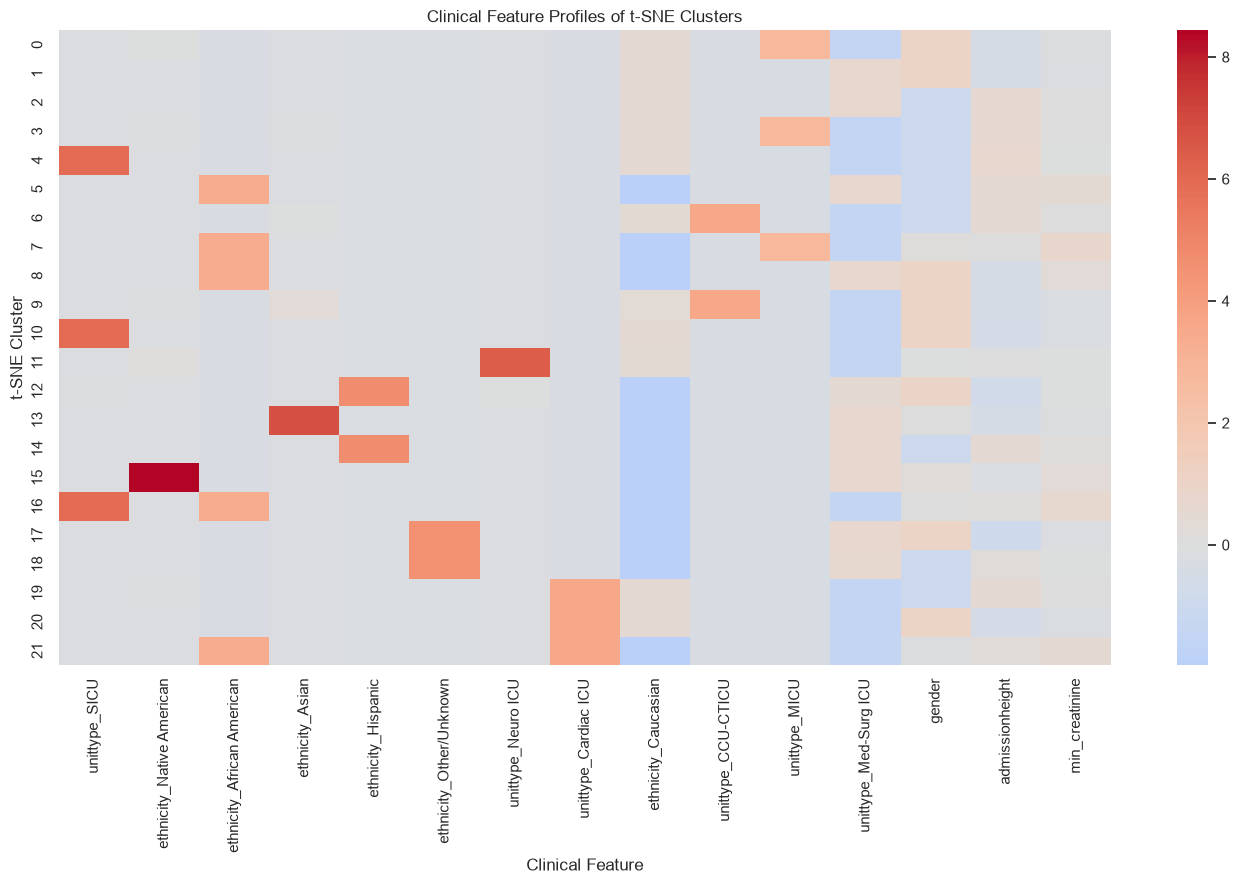

In [37]:
plt.figure(figsize=(14, 9))

# Display whether each important feature
# is relatively high or low within each cluster
sns.heatmap(
    cluster_profiles[
        top_profile_features
    ],
    cmap="coolwarm",
    center=0
)

plt.title(
    "Clinical Feature Profiles of t-SNE Clusters"
)

plt.xlabel("Clinical Feature")
plt.ylabel("t-SNE Cluster")

plt.tight_layout()

plt.savefig(
    PLOTS_DIR / "tsne_cluster_feature_heatmap.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

#### Observation :
- Creates a heatmap of the $15$ most distinguishing clinical features across all $22$ clusters.
- Shows whether each feature is higher or lower than the overall patient average within each cluster.
- Helps identify the clinical characteristics that differentiate the patient subgroups.
- Saves the heatmap for reporting and interpretation.

## Save Essential Results

### Save t-SNE Cluster Assignments

In [38]:
# Save patient IDs, t-SNE coordinates, and cluster labels
tsne_results.to_csv(
    RESULTS_DIR / "tsne_dbscan_clusters.csv",
    index=False
)

print(
    "Saved: tsne_dbscan_clusters.csv"
)

Saved: tsne_dbscan_clusters.csv


### Save Internal Evaluation Summary

In [39]:
# Save our clustering metrics and Ju and Dubin benchmarks
evaluation_summary.to_csv(
    RESULTS_DIR / "tsne_evaluation_summary.csv",
    index=False
)

print(
    "Saved: tsne_evaluation_summary.csv"
)

Saved: tsne_evaluation_summary.csv


### Save Clinical Outcome Summary

In [40]:
# Save the clinical characteristics of every cluster
clinical_summary.to_csv(
    RESULTS_DIR / "tsne_clinical_summary.csv",
    index=False
)

print(
    "Saved: tsne_clinical_summary.csv"
)

Saved: tsne_clinical_summary.csv


## Final Summary

In [42]:
print("t-SNE + DBSCAN Final Summary")
print("=" * 45)

print()
print("Dataset")

print(
    "Patients:",
    len(tsne_results)
)

print(
    "Clustering features:",
    len(feature_cols)
)


print()
print("t-SNE Parameters")

print(
    "Dimensions:",
    TSNE_COMPONENTS
)

print(
    "Perplexity:",
    TSNE_PERPLEXITY
)

print(
    "Metric: Euclidean"
)

print(
    "Random state:",
    RANDOM_STATE
)


print()
print("DBSCAN Parameters")

print(
    "Epsilon:",
    DBSCAN_EPS
)

print(
    "Min samples:",
    DBSCAN_MIN_SAMPLES
)


print()
print("Clustering Result")

print(
    "Clusters:",
    n_clusters
)

print(
    "Outliers:",
    n_outliers
)

print(
    "Outlier percentage:",
    round(outlier_percentage, 2),
    "%"
)


print()
print("Internal Evaluation")

print(
    "Silhouette Score:",
    round(silhouette, 4)
)

print(
    "Davies-Bouldin Index:",
    round(dbi, 4)
)

print(
    "Calinski-Harabasz Index:",
    round(chi, 2)
)


print()
print("Survival Evaluation")

print(
    "Patients:",
    len(survival_data)
)

print(
    "ICU deaths:",
    int(
        survival_data["icu_mortality"].sum()
    )
)

print(
    "Log-rank statistic:",
    round(
        logrank_result.test_statistic,
        4
    )
)

print(
    "Log-rank p-value:",
    logrank_result.p_value
)

t-SNE + DBSCAN Final Summary

Dataset
Patients: 7648
Clustering features: 80

t-SNE Parameters
Dimensions: 2
Perplexity: 80
Metric: Euclidean
Random state: 42

DBSCAN Parameters
Epsilon: 3.0
Min samples: 40

Clustering Result
Clusters: 22
Outliers: 310
Outlier percentage: 4.05 %

Internal Evaluation
Silhouette Score: 0.6621
Davies-Bouldin Index: 0.2744
Calinski-Harabasz Index: 8528.12

Survival Evaluation
Patients: 7338
ICU deaths: 949
Log-rank statistic: 21.9247
Log-rank p-value: 0.4038589768514318


## Difference between my Parameters and Ju and Dubin Paper

| Method | Parameter              | Ju and Dubin                                             | My Parameter    |
| ------ | ---------------------- | -------------------------------------------------------- | --------------- |
| t-SNE  | Input scaling          | Min-Max scaling                                          | Min-Max scaling |
| t-SNE  | Distance metric        | Euclidean                                                | Euclidean       |
| t-SNE  | Embedding dimensions   | 2                                                        | 2               |
| t-SNE  | Perplexity             | Not reported                                             | 80              |
| t-SNE  | Initialization         | Not reported                                             | PCA             |
| t-SNE  | Learning rate          | Not reported                                             | Auto            |
| t-SNE  | Iterations             | Not reported                                             | 1000            |
| t-SNE  | Random seed            | Not reported                                             | 42              |
| DBSCAN | Epsilon                | Selected using k-distance knee, exact value not reported | 3.0             |
| DBSCAN | `min_samples` / MinPts | 50                                                       | 40              |
